<a href="https://colab.research.google.com/github/abhishekCS0024/LangGraph/blob/main/HITL_in_Customer_Support.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
!pip install langchain langchain_core langchain_groq langchain_community langchain langgraph

In [55]:
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate

In [56]:
from langchain_groq import ChatGroq
from google.colab import userdata

In [57]:
llm=ChatGroq(
    temperature=0,
    groq_api_key=userdata.get('Groq'),
    model_name="qwen/qwen3-32b",
    verbose=True
)

In [58]:
class State(TypedDict):
    query: str
    category: str
    sentiment: str
    response: str
    human_feedback: str  # ✅ Add this

In [59]:
from pydantic import BaseModel, Field
from typing import Literal

class Category(BaseModel):
  category:Literal["Technical", "Billing", "General"] = Field(description='The category of issue mentioned in the review')

class Tone(BaseModel):
  tone:Literal['Positive', 'Neutral', 'Negative'] = Field(description='The tone of  the  query of the customers')

In [60]:
def category(State):
    """Categorize the customer query into Technical, Billing, or General."""

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a highly efficient customer support triage assistant. "
         "Categorize the customer query into exactly one of: "
         "Technical, Billing, or General."),
        ("human",
         "Here is the customer query: {query}")
    ])

    llm_category = llm.with_structured_output(Category)

    category_obj = llm_category.invoke(
        prompt.format_messages(query=State["query"])
    )
    return {"category": category_obj.category}

In [61]:
def sentiment(State):
  """In order to find the tone of the customers"""
  llm_sentiment=llm.with_structured_output(Tone)

  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "You are a highly efficient customer support triage assistant. listen the user query & analyze the user tone of the query"
          ),
          ("human",
           "Here is the customer query: {query}, Analyze the tone of the query"
          )
      ]
  )

  sentiment_obj = llm_sentiment.invoke(
      prompt.format_messages(query=State["query"])
  )
  return {"sentiment": sentiment_obj.tone}

In [62]:
def Technical(State):
  """Your are the technical support """
  print("Technical")
  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "You are a Senior Tier-3 Technical Support Engineer specializing in mobile and web applications. Your goal is to provide deep-level troubleshooting for app malfunctions, bugs, and functional failures."),
          ("human",
           "here is the customer query: {query}"),
      ]
  )

  response = llm.invoke(prompt.format_messages(query=State["query"]))
  return {"response": response}

def Billing(State):
  """Your are the technical support """
  print("Billing query")
  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "Your are senior finance officer of the company, your have experience of the accounts & billing"),
          ("human",
           "here is the customer query: {query}"),
      ]
  )

  response = llm.invoke(prompt.format_messages(query=State["query"]))
  return {"response": response}

def General(State):
  """Your are the technical support """

  print("General query")

  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "Your are the Customer support agent, that handle the customers genenuine  issue "),
          ("human",
           "here is the customer query: {query}"),
      ]
  )

  response = llm.invoke(prompt.format_messages(query=State["query"]))
  return {"response": response}

In [63]:
def Escalate(state: State):
    """Escalate with optional human agent override."""
    print("Escalating to human agent...")
    feedback = state.get("human_feedback", "").strip()

    # Above code meaning

    # if "human_feedback" in state:
    #     feedback = state["human_feedback"]
    # else:
    #     feedback = ""

    if feedback:
        return {"response": f"[Human Agent Response]: {feedback}"}
    return {"response": "This query has been escalated to a human agent due to its negative sentiment."}

In [64]:
def route_query(State):
    if State["sentiment"] == "Negative":
        return "negative"       # ✅ Escalate ANY negative query first
    elif State["category"] == "Technical":
        return "Technical"
    elif State["category"] == "Billing":
        return "Billing"
    else:
        return "General"

In [65]:
workflow=StateGraph(State)

In [66]:
from langgraph.graph import StateGraph, START, END

# Re-initialize the workflow to avoid 'Branch already exists' error on re-execution
# 'State' is assumed to be defined in a previous cell.
workflow = StateGraph(State)

# Add nodes (moved from Rg2vXipyF3qX to ensure they are added after re-initialization)
workflow.add_node("categorize", category)
workflow.add_node("analyze_sentiment", sentiment)
workflow.add_node("handle_technical", Technical)
workflow.add_node("handle_billing", Billing)
workflow.add_node("handle_general", General)
workflow.add_node("escalate", Escalate)

workflow.add_edge(START,"categorize")
workflow.add_edge("categorize","analyze_sentiment")

workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    {
        "Technical": "handle_technical",
        "Billing": "handle_billing",
        "negative": "escalate",
        "General": "handle_general"
    }
)

workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)

In [67]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

app = workflow.compile(
    checkpointer=checkpointer,
    interrupt_before=["escalate"]  # ✅ Pause before escalation
)

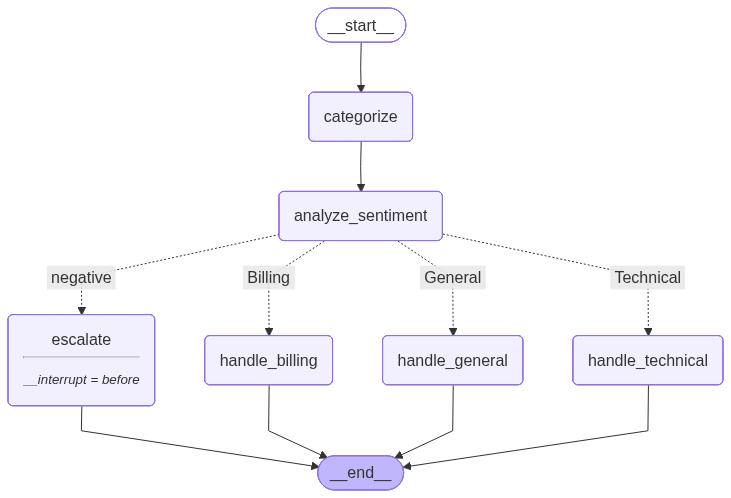

In [68]:
app

# HITL

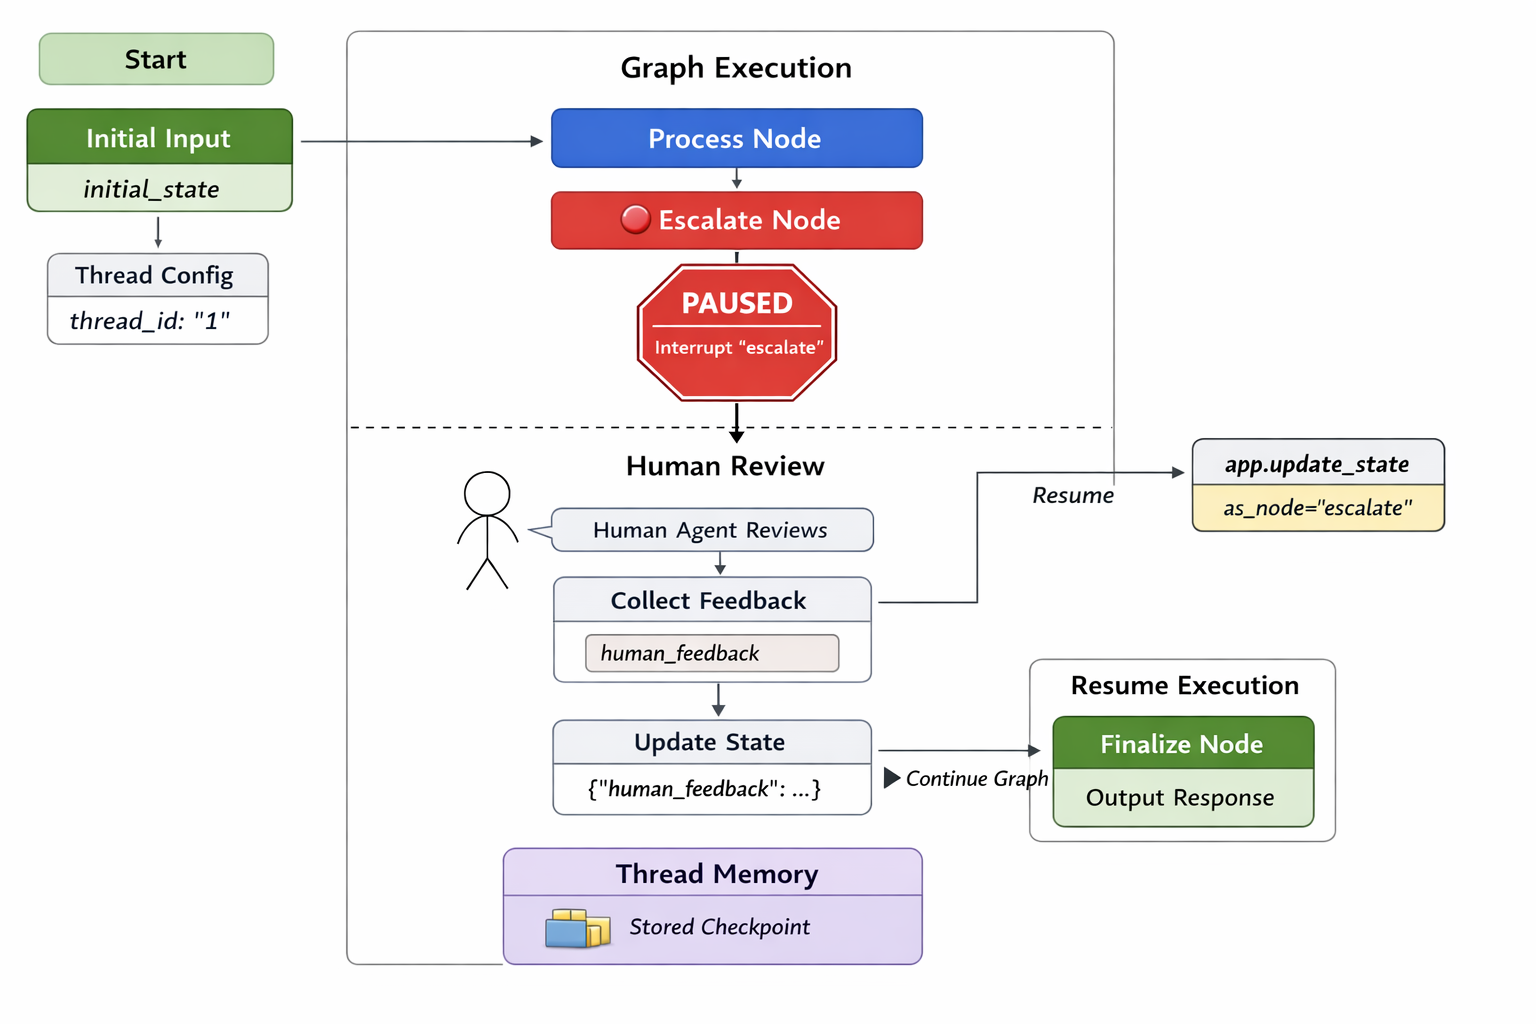

In [73]:
thread = {"configurable": {"thread_id": "1"}}

initial_state = {
    "query": "I was charged twice and nobody is helping me, this is unacceptable!",
    "category": None,
    "sentiment": None,
    "response": None,
    "human_feedback": None
}

# ▶ Run until interrupt
for event in app.stream(initial_state, thread, stream_mode="values"):
    print(event)

# 🔍 Check if paused before escalate
state_snapshot = app.get_state(thread)
print("⏸ Paused at:", state_snapshot.next)

# 👤 Human reviews and provides input
if "escalate" in state_snapshot.next:
    print(f"\n📋 Query: {state_snapshot.values['query']}")
    print(f"😠 Sentiment: {state_snapshot.values['sentiment']}")

    human_input = input("\n✍️ Human Agent — Enter your response (or press Enter to auto-escalate): ")

    # Inject human feedback into state
    # app.update_state(thread, {"human_feedback": human_input}, as_node="escalate")
    app.update_state(thread, {"human_feedback": human_input})

# ▶ Resume graph from where it paused
for event in app.stream(None, thread, stream_mode="values"):
    print(event)

# ✅ Final result
print("\n📨 Final Response:", app.get_state(thread).values["response"])

{'query': 'I was charged twice and nobody is helping me, this is unacceptable!', 'category': None, 'sentiment': None, 'response': None, 'human_feedback': None}
{'query': 'I was charged twice and nobody is helping me, this is unacceptable!', 'category': 'Billing', 'sentiment': None, 'response': None, 'human_feedback': None}
{'query': 'I was charged twice and nobody is helping me, this is unacceptable!', 'category': 'Billing', 'sentiment': 'Negative', 'response': None, 'human_feedback': None}
⏸ Paused at: ('escalate',)

📋 Query: I was charged twice and nobody is helping me, this is unacceptable!
😠 Sentiment: Negative

✍️ Human Agent — Enter your response (or press Enter to auto-escalate): good
{'query': 'I was charged twice and nobody is helping me, this is unacceptable!', 'category': 'Billing', 'sentiment': 'Negative', 'response': None, 'human_feedback': 'good'}
Escalating to human agent...
{'query': 'I was charged twice and nobody is helping me, this is unacceptable!', 'category': 'Bil

In [71]:
State["response"]

__main__.State['response']